# Chord length: two-point-correlation method vs. direct sampling

Tests the two chord-length estimators added at the end of `smds.py` (`chord_length_from_S2` and
`sample_chords_nd` / `chord_pdf`), and compares them with `compare_chord_methods()` on a real 2D
slice and a 3D sub-volume of the XCT sandstone test image.

- **Method 1 (`chord_length_from_S2`)**: mean chord length from the slope of S2(r) at r=0
  (Torquato, *Random Heterogeneous Materials*, Eq. 2.74).
- **Method 2 (`sample_chords_nd` + `chord_pdf`)**: direct run-length sampling of foreground/
  background segments along scan lines, giving the full chord-length distribution p(z) and its
  mean.

**Requirements:** run with a kernel from the `gui_micro` conda env (`numpy`, `numba`, `pandas`,
`matplotlib`, `tifffile`).

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so `from src.micro_gui...` resolves the same way calculate_SMD.py does

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile

from src.micro_gui.analysis.smds import (
    calculate_s2,
    calculate_s2_3d,
    chord_length_from_S2,
    sample_chords_nd,
    chord_pdf,
    compare_chord_methods,
)

## 1. Load the 2D test image

2D image shape: (512, 512), pore (phase=1) fraction: 0.2504


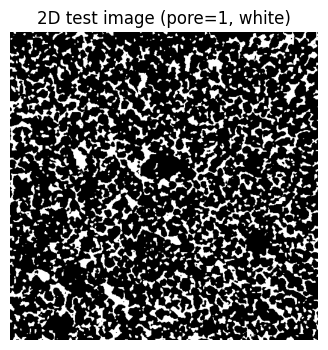

In [2]:
IMAGE_PATH_2D = "../test_images/XCT_11.4um_binary0000.tif"

img2d = tifffile.imread(IMAGE_PATH_2D).astype(np.uint8)
print(f"2D image shape: {img2d.shape}, pore (phase=1) fraction: {img2d.mean():.4f}")

plt.figure(figsize=(4, 4))
plt.imshow(img2d, cmap="gray")
plt.title("2D test image (pore=1, white)")
plt.axis("off")
plt.show()

## 2. 2D: compute S2 and run the chord-length comparison for phase=1

`compare_chord_methods` needs `s2_phase`, the radial S2 of the phase of interest (`phase=1`,
foreground), from `calculate_s2`. It then runs `chord_length_from_S2` (Method 1) and
`sample_chords_nd`/`chord_pdf` (Method 2) for that same phase and prints a side-by-side table.

In [ ]:
s2_2d = calculate_s2(img2d)

# num_points defaults to 2 now (validated below) - the S2 curve is concave near
# r=0, so a wider linear-fit window underestimates the slope and overestimates
# the chord length (see section 3).
results_2d = compare_chord_methods(img2d, s2_2d, phase=1)
results_2d

## 3. 2D: is Method 1 stable as `num_points` changes?

`chord_length_from_S2`'s `num_points` controls how many small-r samples are used to fit the S2
slope at the origin. The sweep below shows it is **not** stable across a wide range: S2(r) is
concave near r=0, so widening the fit window underestimates the slope magnitude and inflates the
chord-length estimate. `num_points=2` (a plain one-pixel secant) tracks the direct method
(flat reference line) closely - that's why it's now the function's default.

In [ ]:
num_points_range = range(2, 15)
ell_s2_list = [chord_length_from_S2(s2_2d, num_points=n, dr=1.0) for n in num_points_range]

ell_direct_2d = results_2d["direct"]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(num_points_range), ell_s2_list, "o-", label="via S2")
ax.axhline(ell_direct_2d, color="C1", ls="--", alpha=0.6, label="direct")
ax.set_xlabel("num_points used for the S2 slope fit")
ax.set_ylabel("mean chord length, phase=1 (pixels)")
ax.set_title("2D: Method 1 sensitivity to num_points")
ax.legend()
plt.tight_layout()
plt.show()

## 4. 2D: visualize the chord-length distribution and the S2 slope fit

Left: empirical chord-length PDF `p(z)` for phase=1 (Method 2), with the mean marked.
Right: S2(r) near r=0 with the linear fit used by Method 1 overlaid, so the fitted slope can be
checked visually against the actual curve.

In [ ]:
chords_2d = sample_chords_nd(img2d, phase=1)
z_2d, p_2d, mean_direct_2d = chord_pdf(chords_2d)

num_points_fit = 2  # matches chord_length_from_S2's new default
r_fit = np.arange(num_points_fit)
slope, intercept = np.polyfit(r_fit, s2_2d[:num_points_fit], 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(z_2d, p_2d, width=(z_2d[1] - z_2d[0]), alpha=0.7, color="C0")
axes[0].axvline(mean_direct_2d, color="k", ls="--", label=f"mean = {mean_direct_2d:.2f}")
axes[0].set_title("Chord-length PDF, phase=1 (direct)")
axes[0].set_xlabel("chord length (pixels)")
axes[0].legend()

r_plot = np.arange(20)
axes[1].plot(r_plot, s2_2d[:20], "o-", ms=4, label="S2(r)")
axes[1].plot(r_fit, intercept + slope * r_fit, "r--", lw=2, label=f"fit (n={num_points_fit})")
axes[1].set_title("S2(r) near r=0, Method 1 fit")
axes[1].set_xlabel("r (pixels)")
axes[1].set_ylabel("S2(r)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Load the 3D test image

The full volume is 512x512x512. `calculate_s2_3d`'s cost scales roughly as (volume size)^4
(three directions, each an O(n^2 x n^2) double loop), so the full volume would take several
minutes. A 200^3 sub-volume keeps this notebook fast (a couple of seconds) while still being
large enough for a meaningful chord-length distribution.

Full 3D volume shape: (512, 512, 512)
3D sub-volume shape: (200, 200, 200), pore (phase=1) fraction: 0.2348


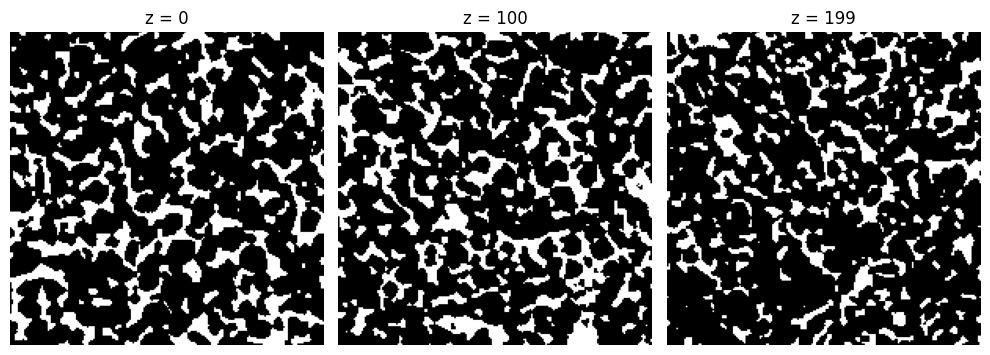

In [6]:
IMAGE_PATH_3D = "../test_images/XCT_11.4um_binary.tif"
CROP = 200

full3d = tifffile.imread(IMAGE_PATH_3D).astype(np.uint8)
print(f"Full 3D volume shape: {full3d.shape}")

img3d = full3d[:CROP, :CROP, :CROP].copy()
print(f"3D sub-volume shape: {img3d.shape}, pore (phase=1) fraction: {img3d.mean():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
for ax, idx in zip(axes, [0, CROP // 2, CROP - 1]):
    ax.imshow(img3d[idx], cmap="gray")
    ax.set_title(f"z = {idx}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 6. 3D: compute S2 and run the chord-length comparison for phase=1

In [ ]:
s2_3d = calculate_s2_3d(img3d)

results_3d = compare_chord_methods(img3d, s2_3d, phase=1)
results_3d

## 7. 3D: Method 1 sensitivity to `num_points`

In [ ]:
num_points_range_3d = range(2, 15)
ell_s2_list_3d = [chord_length_from_S2(s2_3d, num_points=n, dr=1.0) for n in num_points_range_3d]

ell_direct_3d = results_3d["direct"]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(num_points_range_3d), ell_s2_list_3d, "o-", label="via S2")
ax.axhline(ell_direct_3d, color="C1", ls="--", alpha=0.6, label="direct")
ax.set_xlabel("num_points used for the S2 slope fit")
ax.set_ylabel("mean chord length, phase=1 (voxels)")
ax.set_title("3D: Method 1 sensitivity to num_points")
ax.legend()
plt.tight_layout()
plt.show()

## 8. 3D: chord-length distribution and the S2 slope fit

In [ ]:
chords_3d = sample_chords_nd(img3d, phase=1)
z_3d, p_3d, mean_direct_3d = chord_pdf(chords_3d)

num_points_fit = 2  # matches chord_length_from_S2's new default
r_fit = np.arange(num_points_fit)
slope_3d, intercept_3d = np.polyfit(r_fit, s2_3d[:num_points_fit], 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(z_3d, p_3d, width=(z_3d[1] - z_3d[0]), alpha=0.7, color="C0")
axes[0].axvline(mean_direct_3d, color="k", ls="--", label=f"mean = {mean_direct_3d:.2f}")
axes[0].set_title("Chord-length PDF, phase=1 (direct, 3D)")
axes[0].set_xlabel("chord length (voxels)")
axes[0].legend()

r_plot = np.arange(20)
axes[1].plot(r_plot, s2_3d[:20], "o-", ms=4, label="S2(r)")
axes[1].plot(r_fit, intercept_3d + slope_3d * r_fit, "r--", lw=2, label=f"fit (n={num_points_fit})")
axes[1].set_title("S2(r) near r=0, Method 1 fit (3D)")
axes[1].set_xlabel("r (voxels)")
axes[1].set_ylabel("S2(r)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Summary table: 2D vs. 3D, phase=1

In [ ]:
summary = pd.DataFrame(
    [
        {"case": "2D", "phase": 1, "via_S2": results_2d["via_S2"], "direct": results_2d["direct"]},
        {"case": "3D", "phase": 1, "via_S2": results_3d["via_S2"], "direct": results_3d["direct"]},
    ]
)
summary["rel_diff_%"] = (
    (summary["via_S2"] - summary["direct"]).abs() / summary["direct"] * 100
)
summary